# Example : Aumann-Shapley Ratio Decomposition

This notebook demonstrates how to:
- Load the sample Kaggle CSV (from `../csv/Kaggle.csv`)
- Clean column names and numeric fields
- Compute Aumann-Shapley ratio decomposition between female and male subsets
- Visualize ratio changes and run subgroup discovery on `BEL_effect`

Usage:
1. Make sure `../csv/Kaggle.csv` exists relative to this notebook.
2. Run the cells top-to-bottom.
3. Review plots and the printed `df_summary`.

Notes:
- You may see `SettingWithCopyWarning` from pandas when slicing; results are still produced.
- To use another dataset, update the `path` in the CSV loading cell.


In [1]:
import re
import pandas as pd
import os

from aumann_ratio_decomposition import (
    AumannShapleyRatioDecomposer,
    SDConfig,
    SubgroupLooper,
)

In [2]:
# ================================================================
# CSV preprocessing step (not core to the Aumann-Shapley logic)
# - Load Kaggle source CSV
# - Sanitize column names for safe Python attribute access
# - Clean numeric fields & normalize types
# - Convert dates into numerical features
# - Create grouped age bins and prepare num/den fields for ratio analysis
# ==============================================================

# Load raw Kaggle dataset (semicolon delimited, European formatted numbers, date parsing)
path = "../csv/Kaggle.csv"       # CSV relative path for this notebook
df = pd.read_csv(path, sep=';', thousands=',', parse_dates=['Issue Date'], dayfirst=True)

if not os.path.exists(path):
    raise FileNotFoundError(
        "Kaggle.csv is missing in '../csv'.\n"
        "[EN] Please download the CSV dataset referenced in the paper and save it as "
        "'Kaggle.csv' in the 'csv' folder.\n"
        "[JA] '../csv' フォルダ内に Kaggle.csv が見つかりません。論文に記載された参考文献から "
        "元データの CSV をダウンロードし、ファイル名を 'Kaggle.csv' として 'csv' フォルダに保存してください。"
    )

# --- Column name cleanup (not logically important, just to avoid symbols/spaces) ---
def make_safe_colnames(cols):
    mapping = {}
    for col in cols:
        safe = re.sub(r"[^A-Za-z0-9_]", "_", col)   # Replace abnormal chars with "_"
        safe = re.sub(r"_+", "_", safe).strip("_")  # Collapse multiple underscores
        if safe and safe[0].isdigit():              # Avoid leading numbers in column names
            safe = "_" + safe
        mapping[col] = safe
    return mapping

rename_map = make_safe_colnames(df.columns)
df = df.rename(columns=rename_map)


# --- Numeric column cleaning (strip currency/letters before converting to float) ---
clean = (df['Premium'].astype(str)
                      .str.replace(r'[^\d\.\-]', '', regex=True))      # Keep only digits, dots, minus
df['Premium'] = pd.to_numeric(clean, errors='coerce') 

clean = (df['BENEFIT'].astype(str)
                      .str.replace(r'[^\d\.\-]', '', regex=True))
df['BENEFIT'] = pd.to_numeric(clean, errors='coerce') 


# --- Date parsing & decomposition into year/month/day features ---
df['Issue_Date'] = pd.to_datetime(df['Issue_Date'], format='%b-%y', errors='coerce')
df['Issue_year']  = df['Issue_Date'].dt.year.astype("Int16")
df['Issue_month'] = df['Issue_Date'].dt.month.astype("Int8")
df['Issue_day']   = df['Issue_Date'].dt.dayofyear.astype("Int16")
df.drop(columns=['Issue_Date'], inplace=True)


# --- Feature engineering ---
df['ENTRY_AGE_RANK'] = df['ENTRY_AGE'].astype("Int8") // 10 * 10   # Age grouped into 10-year bins


# --- Build ratio components ---
df['den'] = df['Premium'].fillna(df['Premium'].mean())  # Fill NA with mean premium
df['den'] = df['den'].abs()                             # Absolute value used as denominator
df['numtest'] = df['POLICY_STATUS'].apply(lambda x: 1 if x == 'Lapse' else 0)  # Lapse indicator
df['num'] = df['numtest'] * df['den']                   # Weighted lapse count as numerator


# --- Split into Male/Female datasets (SEX drops as no longer needed) ---
df_f = df[df['SEX'] == 'F'].drop(columns=['SEX'])
df_m = df[df['SEX'] == 'M'].drop(columns=['SEX'])


C:\Users\batam\AppData\Local\Temp\ipykernel_25324\3066613709.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(path, sep=';', thousands=',', parse_dates=['Issue Date'], dayfirst=True)


### Example: Run Aumann–Shapley Ratio Decomposition (Male vs Female)

In this example, we apply **AumannShapleyRatioDecomposer** using the preprocessed datasets
`df_f` (Female) as the baseline population and `df_m` (Male) as the comparison population.

Note that both `df_before` and `df_after` must be specified.
Aumann–Shapley allocation requires two populations (before vs after) to measure and distribute ratio differences.

**Key Parameters**

* `mode="group"`: Performs decomposition **after minimal aggregation**, grouping records by `keys` first
* `mode="detail"`: Performs decomposition **directly on raw records** without pre-aggregation
* `num_col` / `den_col`: Specify the **numerator and denominator column names** used for the ratio calculation
* `decompose_keys=[...]`: One or more **subgroup dimensions for decomposition**
  (multiple keys may be provided, e.g. age rank × product type)

**What the code below will do**

1. Compare Female (`df_f`) vs Male (`df_m`) populations
2. Compute Aumann–Shapley contribution allocation for the ratio difference
3. Plot stacked ratio decomposition by `ENTRY_AGE_RANK` over policy years
4. Retrieve numerical decomposition results in `ret`

After running, review:

* The stacked plot showing contribution trends by age segment
* `ret`, the summary DataFrame containing the decomposition output


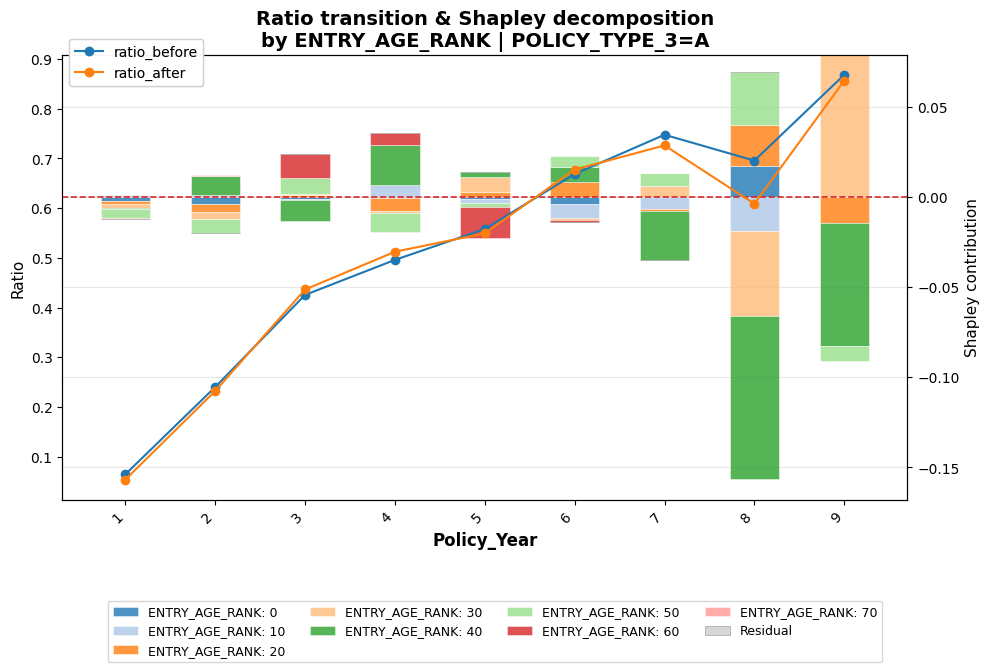

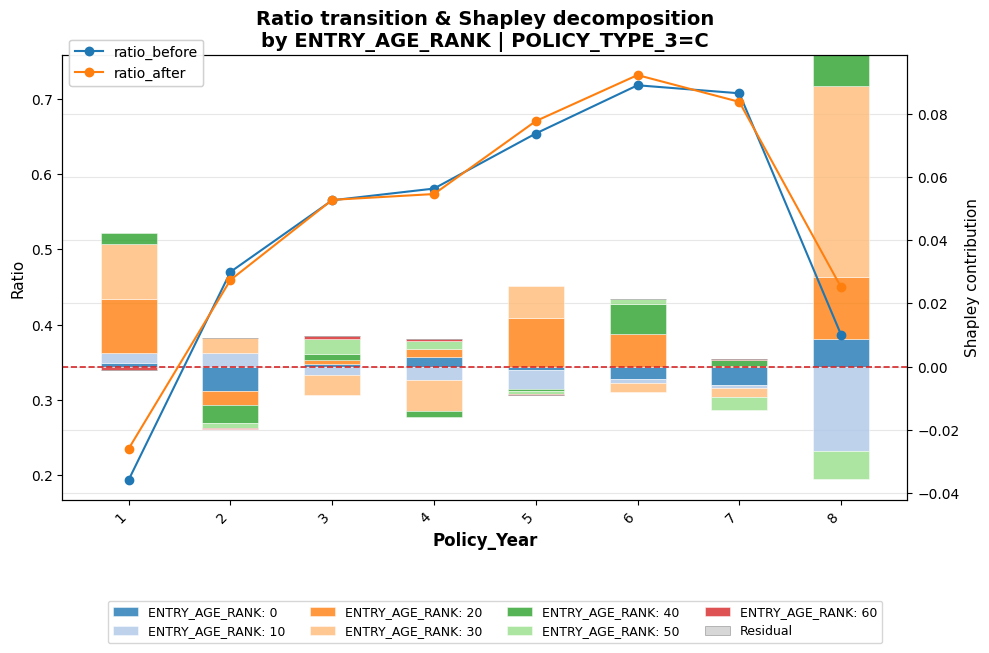

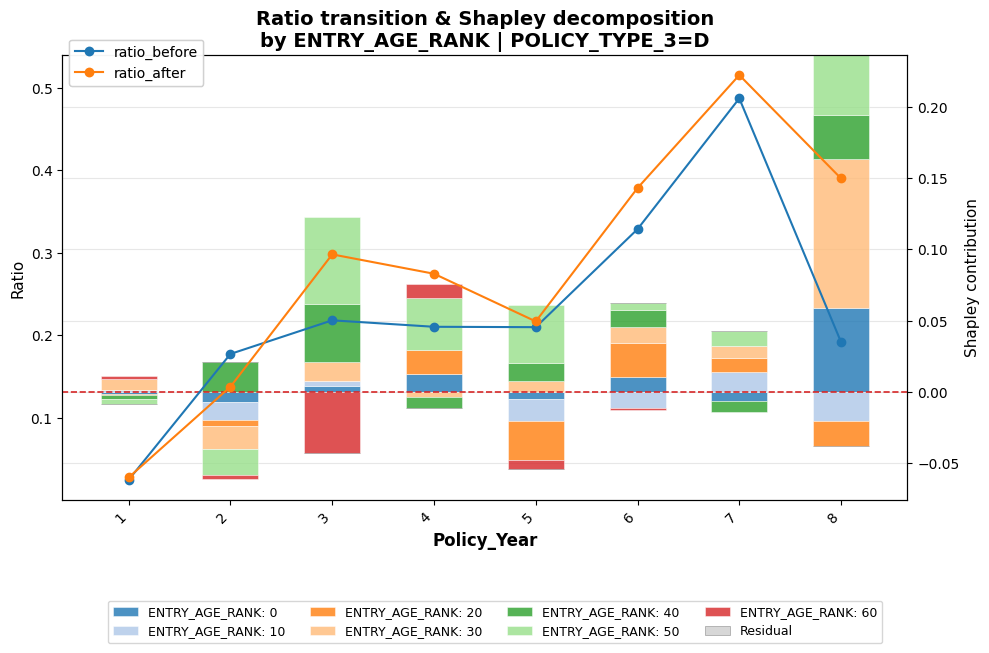

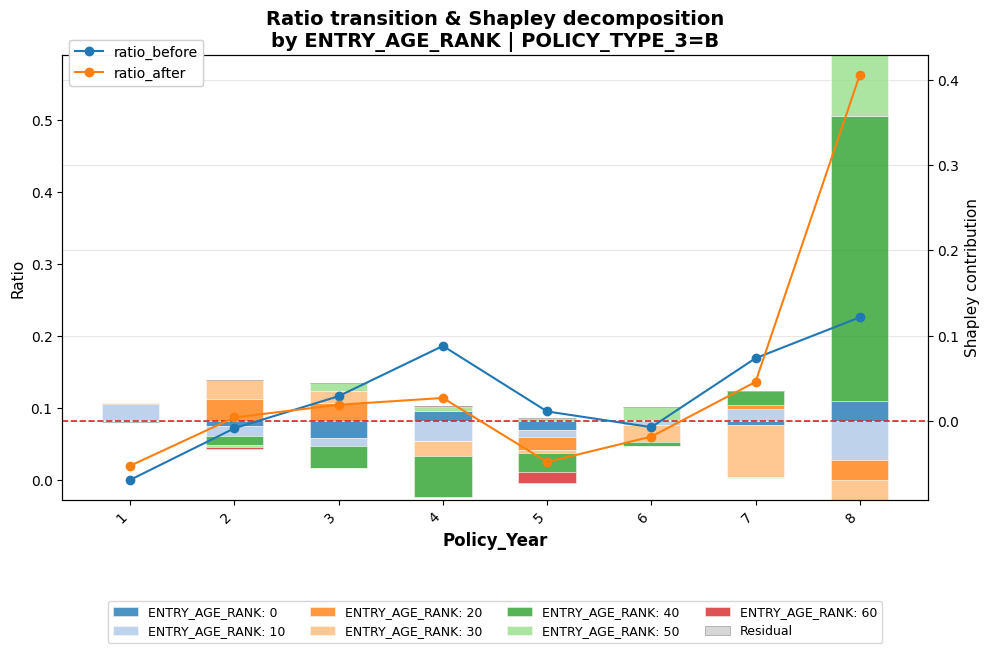

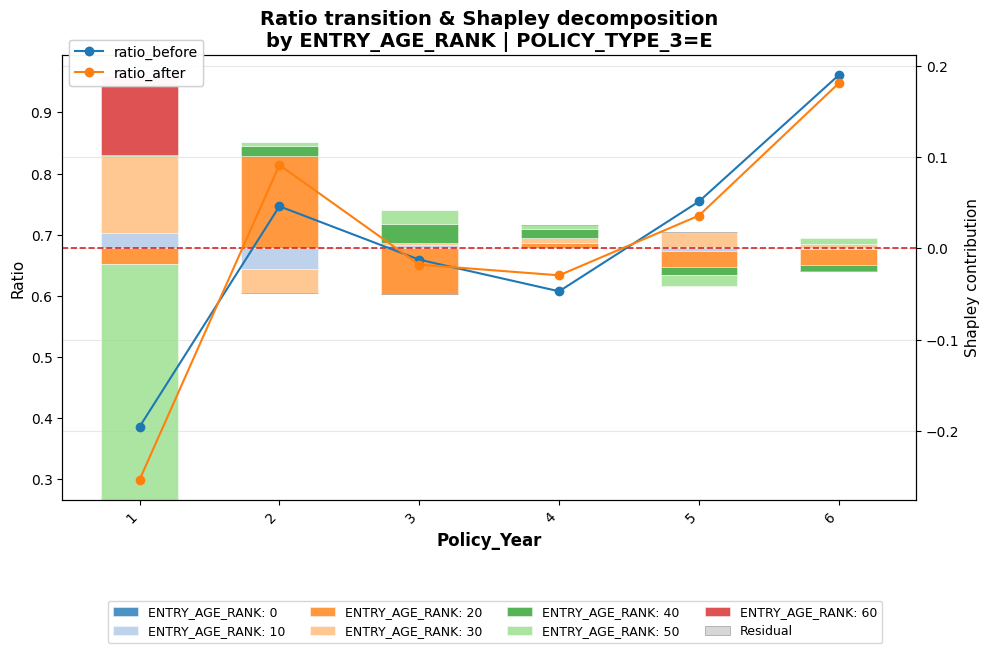

,Unnamed_20,Issue_day,NUMBER_OF_ADVANCE_PREMIUM,NON_LAPSE_GUARANTEED,Unnamed_21,POLICY_TYPE_3,CHANNEL3,Issue_month,PAYMENT_MODE,SUBSTANDARD_RISK,...,CHANNEL2,ENTRY_AGE_RANK,POLICY_TYPE_2,den_bef,num_bef,den_aft,num_aft,den,num,aumann_shapley
0,0.0,1,0,NLG Active,0.0,A,0,1,Monthly,0.0,...,3,20,5,0.000000,0.0,3840.000000,3840.000000,0.000000,0.0,0.000352
1,0.0,1,0,NLG Active,0.0,A,0,1,Monthly,0.0,...,3,20,5,840.000000,0.0,0.000000,0.000000,840.000000,0.0,0.000235
2,0.0,1,0,NLG Active,0.0,C,0,1,Monthly,0.0,...,3,20,17,0.000000,0.0,1273.247877,0.000000,0.000000,0.0,-0.000132
3,0.0,1,0,NLG Active,0.0,C,0,1,Monthly,0.0,...,3,10,9,1273.247877,0.0,0.000000,0.000000,1273.247877,0.0,0.000132
4,0.0,1,0,NLG Active,0.0,C,0,1,Monthly,0.0,...,3,20,17,0.000000,0.0,1273.247877,1273.247877,0.000000,0.0,0.000068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166949,0.0,336,0,NO NLG,0.0,E,57,12,Monthly,0.0,...,2,40,36,0.000000,0.0,6.000000,6.000000,0.000000,0.0,0.000074
166950,0.0,336,0,NO NLG,0.0,E,57,12,Monthly,0.0,...,2,30,36,0.000000,0.0,6.000000,0.000000,0.000000,0.0,-0.000139
166951,0.0,336,0,NO NLG,0.0,E,57,12,Monthly,0.0,...,2,30,38,0.000000,0.0,28.000000,0.000000,0.000000,0.0,-0.000650
166952,0.0,336,0,NO NLG,0.0,E,57,12,Monthly,0.0,...,2,40,30,0.000000,0.0,44.000000,44.000000,0.000000,0.0,0.000539


In [6]:
shapley_my_data = AumannShapleyRatioDecomposer(
        df_before=df_f,
        df_after =df_m,
        mode="group", keys=["POLICY_TYPE_3", "Policy_Year"], den_col="den", num_col="num"
    )

shapley_my_data.plot_ratio_with_shapley_stacked(
    x_key="Policy_Year",
    decompose_keys=["ENTRY_AGE_RANK"],
    figsize=(10,6),
    legend_ncol=4
)

ret = shapley_my_data.result()
ret

📄 Usage: Subgroup Discovery on Aumann–Shapley Derived Effects

This section performs Subgroup Discovery on the post-processed output from  
the Aumann–Shapley ratio decomposition.  
The objective is to identify combinations of features (such as age × product type × channel)  
that have a strong impact on **BEL_effect**, which is a **rough indicator of BEL impact**
derived from Shapley allocation and exposure information.

Steps performed in the code below:

1. Select relevant fields from the Shapley output (`ret`)
2. Compute **BEL_effect as an approximate impact metric**,  
   based on Aumann–Shapley contribution scaled by policy duration and exposure volume  
   (used as a practical proxy rather than an exact BEL calculation)
3. Remove intermediate columns and prepare the dataset for subgroup mining
4. Configure **SubgroupLooper** via `SDConfig` (scoring function, depth, support threshold, binning, etc.)
5. Execute Subgroup Discovery to extract high-impact patterns
6. Visualize the resulting subgroups in a summary plot for interpretation


[Loop 0] remaining=166954, alpha=0.100
  -> picked 1028 rows (12.81% of total target, 87.19% remain), condition: CHANNEL2==1 AND CHANNEL3<15 AND ENTRY_AGE>=44
[Loop 1] remaining=165926, alpha=0.370
  -> picked 1105 rows (15.10% of total target, 72.09% remain), condition: CHANNEL3>=1 AND ENTRY_AGE>=36 AND POLICY_TYPE_3=='D'
[Loop 2] remaining=164821, alpha=0.559
  -> picked 2351 rows (8.66% of total target, 63.43% remain), condition: ENTRY_AGE>=35 AND PAYMENT_MODE=='Annually' AND Policy_Year_Decimal>=5.08
[Loop 3] remaining=162470, alpha=0.691
  -> picked 3868 rows (7.03% of total target, 56.40% remain), condition: ENTRY_AGE>=35 AND POLICY_TYPE_3=='A' AND Policy_Year_Decimal>=5.0
[Loop 4] remaining=158602, alpha=0.784
  -> picked 7637 rows (12.87% of total target, 43.52% remain), condition: ENTRY_AGE<35 AND PAYMENT_MODE=='Annually' AND Policy_Year_Decimal>=1.42
[Loop 5] remaining=150965, alpha=0.849
  -> picked 1769 rows (2.45% of total target, 41.07% remain), condition: CHANNEL3<1 AND 

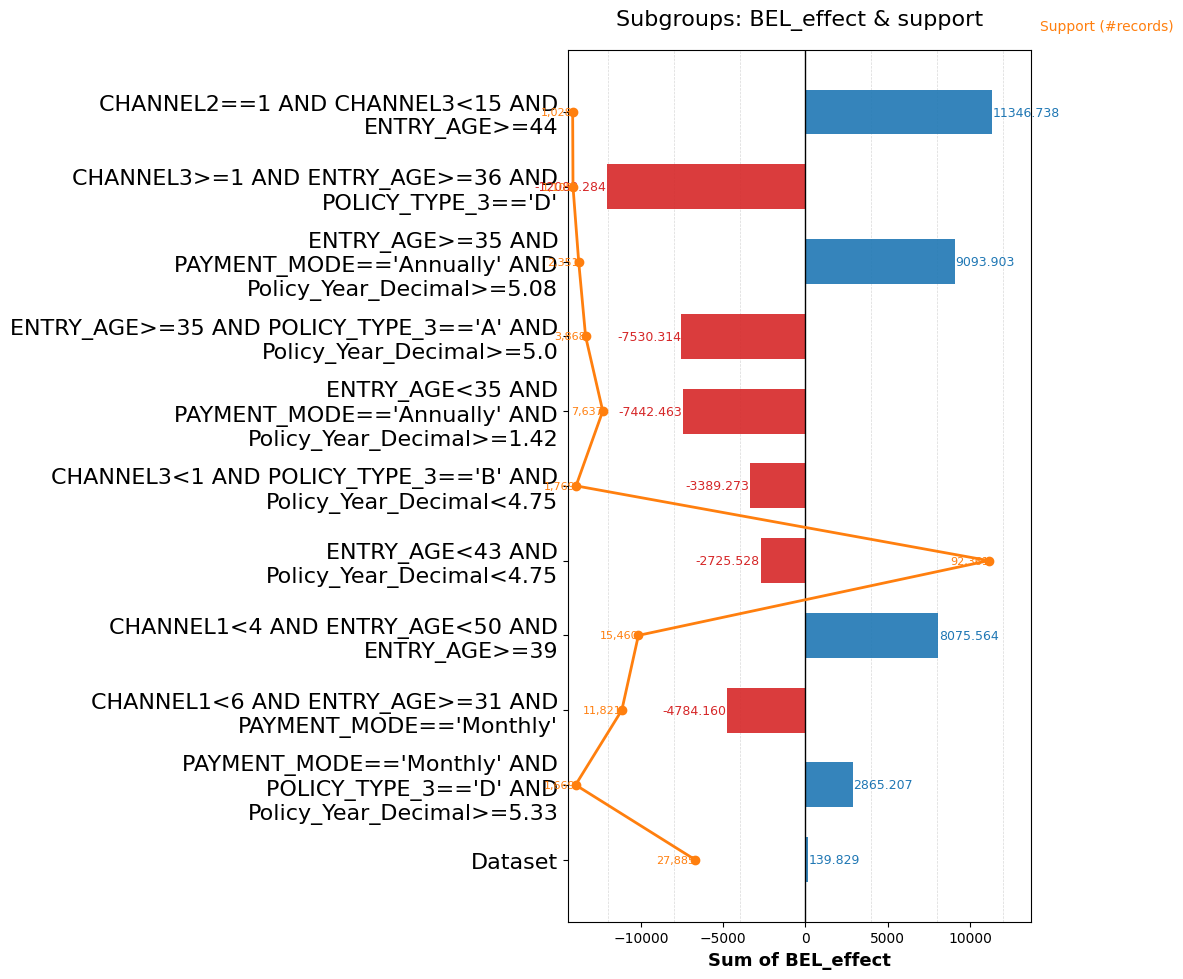

In [4]:
# ===============================================================
# Prepare Aumann–Shapley results for Subgroup Discovery analysis
# (Post-processing step, not the core decomposition logic)
# - Select relevant columns for mining
# - Compute BEL_effect as a weighted AS contribution
#   using year factor and average exposure ((den_bef + den_aft)/2)
# - Drop intermediate columns no longer needed
# ===============================================================

ret_prepped = ret[['Policy_Year_Decimal', 'CHANNEL1', 'CHANNEL2', 'CHANNEL3',
                   'ENTRY_AGE', 'POLICY_TYPE_3', 'PAYMENT_MODE',
                   'aumann_shapley', 'den_bef', 'den_aft']].copy()

ret_prepped['BEL_effect'] = (
    ret_prepped['aumann_shapley']
    * ret_prepped['Policy_Year_Decimal']
    * (ret_prepped['den_bef'] + ret_prepped['den_aft']) / 2  # average exposure
)

ret_prepped = ret_prepped.drop(columns=['den_bef', 'den_aft', 'aumann_shapley'])


# ===============================================================
# Run Subgroup Discovery on BEL_effect
# (search for groups that strongly influence BEL contribution)
# - SDConfig controls mining depth, support thresholds, binning, etc.
# - target_col: outcome for interestingness evaluation
# ===============================================================

cfg = SDConfig(
    target_col='BEL_effect',
    use_abs_std_qf_numeric=True,  # Use absolute StandardQFNumeric scoring
    depth=3,                      # Max rule depth / number of conditions
    alpha_start=0.1,              # Beam search weighting parameter start
    alpha_decay=0.3,              # Weight decay across depths
    min_support=1000,             # Minimum subgroup size
    ratio_threshold=0.1,
    max_loops=None,
    intervals_only=False,
    nbins=5,                      # Discretization bins for numeric attributes
)

runner = SubgroupLooper(ret_prepped, cfg)
df_summary = runner.run()
print(df_summary)

# Plot subgroup results for interpretation
runner.plot(df_summary, wrap_width=40, fig_width=12, font_size=16)
